In [1]:
# @title Dependencias faiss-cpu
%pip install -q huggingface_hub open_clip_torch zarr numcodecs pandas pyarrow numpy matplotlib seaborn scipy
%pip install -q torch torchvision pytorch-lightning transformers sentencepiece wandb tqdm
# RemoteCLIP (metodo oficial ChenDelong): pesos en chendelong/RemoteCLIP via hf_hub_download


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.4 MB/s eta 0:00:00


In [2]:
# @title Hugging Face — descarga dataset
import os
from pathlib import Path

HF_REPO_ID = "Slucu-0310/geovision-cali-sit2"

def _find_dataset_dir() -> Path:
    """Colab, repo local o cwd."""
    here = Path.cwd()
    candidates = [
        Path("/content/dataset_sit2"),
        here / "dataset_sit2",
        here.parent / "dataset_sit2",
    ]
    for p in candidates:
        if (p / "metadatos.parquet").is_file() and (p / "tiles.zarr").exists():
            return p
    return Path("/content/dataset_sit2")

def _eda_run_dirs(data_dir: Path) -> tuple[Path, Path]:
    if str(data_dir).startswith("/content"):
        eda = Path("/content/eda_sit2")
        run = Path("/content/runs/sit2_clip_colab")
    else:
        eda = data_dir.parent / "eda_sit2"
        run = data_dir.parent / "runs" / "sit2_clip_colab"
    eda.mkdir(parents=True, exist_ok=True)
    run.mkdir(parents=True, exist_ok=True)
    return eda, run

DATA_DIR = _find_dataset_dir()
EDA_DIR, RUN_DIR = _eda_run_dirs(DATA_DIR)
print("DATA_DIR:", DATA_DIR, "| existe parquet:", (DATA_DIR / "metadatos.parquet").is_file())

USE_HF_DOWNLOAD = not (DATA_DIR / "metadatos.parquet").is_file()
if USE_HF_DOWNLOAD:
    try:
        from google.colab import userdata
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    except Exception:
        pass
    from huggingface_hub import login, snapshot_download
    if os.environ.get("HF_TOKEN"):
        login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
    DATA_DIR = Path("/content/dataset_sit2")
    EDA_DIR, RUN_DIR = _eda_run_dirs(DATA_DIR)
    snapshot_download(
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        local_dir=str(DATA_DIR),
        local_dir_use_symlinks=False,
    )
    print("Descargado desde HF en:", DATA_DIR)
else:
    print("Usando dataset local (sin re-descargar HF).")



DATA_DIR: /content/dataset_sit2 | existe parquet: False


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 43 files:   0%|          | 0/43 [00:00<?, ?it/s]

Descargado desde HF en: /content/dataset_sit2


In [3]:
# @title Utilidades de lectura (inline)
from __future__ import annotations
import json
from typing import Any, Literal
import numpy as np
import pandas as pd
import zarr

SEED = 42
CLASES = [
    "contaminacion_alta_NO2", "contaminacion_alta_SO2", "ozono_anomalo",
    "vegetacion_densa", "suelo_urbano",
]
BANDAS_S2 = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12","SCL"]
_IDX_RGB = {"B4": 3, "B3": 2, "B2": 1}
_IDX_SCL = BANDAS_S2.index("SCL")

def tile_zarr_index(tile_id: str) -> int:
    """Indice en tiles.zarr alineado con filas del parquet."""
    pos = np.flatnonzero(df["tile_id"].values == tile_id)
    if pos.size == 0:
        raise KeyError(f"tile_id no encontrado: {tile_id}")
    return int(pos[0])

SplitName = Literal["train", "val", "test"]
NUMERIC_COLS = [
    "valid_ratio", "frac_nubes_scl", "frac_claros_scl", "frac_nodata_scl",
    "ndvi", "bsi", "no2", "so2", "o3",
]

def _zarr_store(path: str):
    try:
        return zarr.storage.LocalStore(path)
    except AttributeError:
        return zarr.DirectoryStore(path)

def open_tiles_zarr(zarr_path):
    p = str(zarr_path)
    try:
        root = zarr.open(p, mode="r")
    except Exception:
        root = zarr.open(_zarr_store(p), mode="r")
    if isinstance(root, zarr.Array):
        return root
    if "tiles" in root:
        return root["tiles"]
    for _, a in root.arrays():
        return a
    raise ValueError(p)

def compute_band_stats(zarr_path, n_sample=512, seed=SEED):
    rng = np.random.default_rng(seed)
    arr = open_tiles_zarr(zarr_path)
    n = int(arr.shape[0])
    idx = rng.choice(n, size=min(n_sample, n), replace=False)
    sample = np.stack([np.asarray(arr[i], dtype=np.float32) for i in idx])
    mean = sample.mean(axis=(0, 2, 3))
    std = np.maximum(sample.std(axis=(0, 2, 3)), 1e-3)
    return mean.astype("float32"), std.astype("float32")

def tile_to_rgb_uint8(tile_13hw, p_low=2, p_high=98):
    chans = []
    for b in ("B4", "B3", "B2"):
        x = tile_13hw[_IDX_RGB[b]].astype(np.float32)
        fin = x[np.isfinite(x)]
        lo, hi = (np.percentile(fin, [p_low, p_high]) if fin.size else (0, 1))
        if hi <= lo:
            hi = lo + 1
        chans.append((np.clip((x - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8))
    return np.stack(chans, axis=-1)

META_PATH = DATA_DIR / "metadatos.parquet"
ZARR_PATH = DATA_DIR / "tiles.zarr"
df = pd.read_parquet(META_PATH)
tiles_z = open_tiles_zarr(ZARR_PATH)
secuencias = json.loads((DATA_DIR / "secuencias.json").read_text(encoding="utf-8"))
resumen = json.loads((DATA_DIR / "resumen.json").read_text(encoding="utf-8"))
assert len(df) == int(tiles_z.shape[0])
print(f"Pares: {len(df)} | tiles: {tiles_z.shape}")



Pares: 2263 | tiles: (2263, 13, 64, 64)


## 1. EDA exhaustivo (informe)

Balance, estadísticas por clase, correlaciones y muestras visuales. Salidas en `EDA_DIR`.

=== Balance global ===
 clase
contaminacion_alta_NO2    463
contaminacion_alta_SO2    300
ozono_anomalo             500
vegetacion_densa          500
suelo_urbano              500
Name: n, dtype: int64

=== Balance por split ===
 clase  contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split                                                                  
test                       70                      45             75   
train                     324                     210            350   
val                        69                      45             75   

clase  suelo_urbano  vegetacion_densa  
split                                  
test             75                75  
train           350               350  
val              75                75  


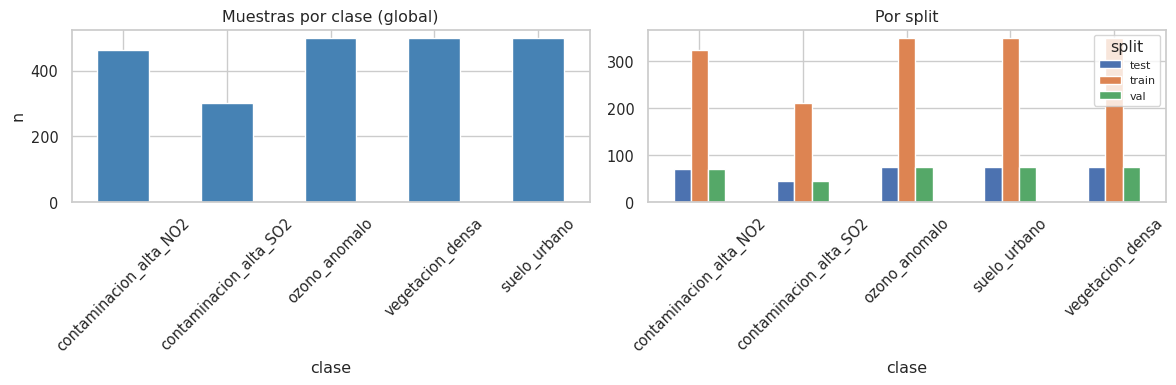


=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===
                            ndvi                                          \
                            mean       std       min       max    median   
clase                                                                      
contaminacion_alta_NO2  0.461170  0.182514  0.030946  0.836661  0.488290   
contaminacion_alta_SO2  0.594777  0.138123  0.111016  0.886132  0.628237   
ozono_anomalo           0.585993  0.135478  0.124191  0.923665  0.603268   
suelo_urbano            0.463727  0.130440  0.014361  0.704629  0.490629   
vegetacion_densa        0.661450  0.082284  0.458566  0.886407  0.664144   

                             bsi                                          ...  \
                            mean       std       min       max    median  ...   
clase                                                                     ...   
contaminacion_alta_NO2 -0.055977  0.124560 -0.346268  0.157995 -0.043124  ...   
contamina

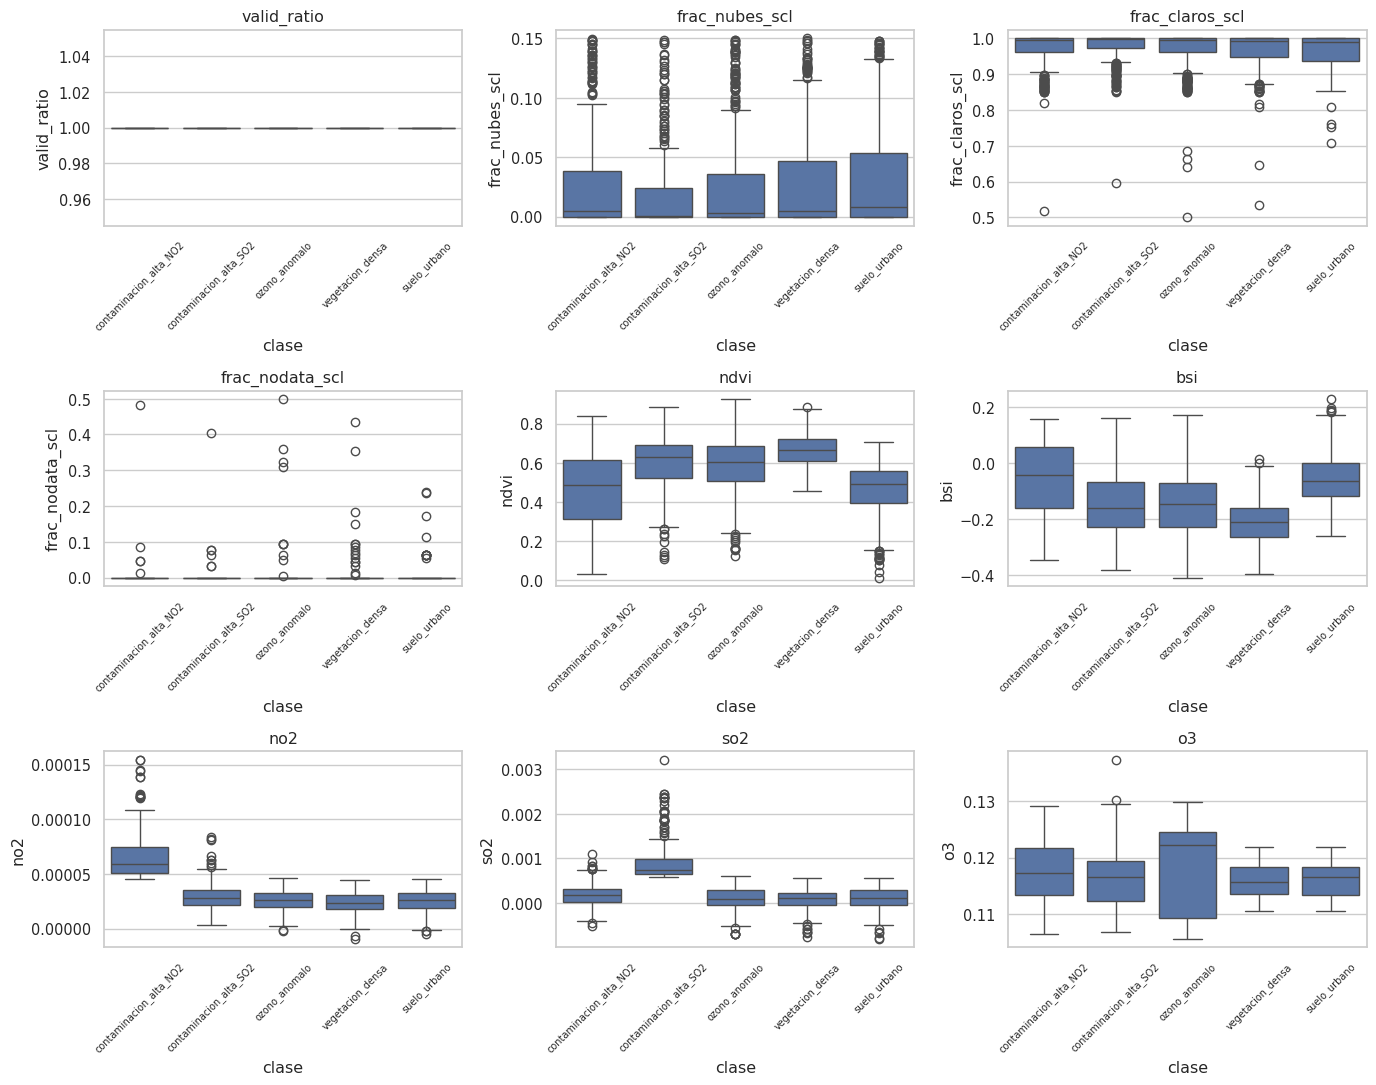

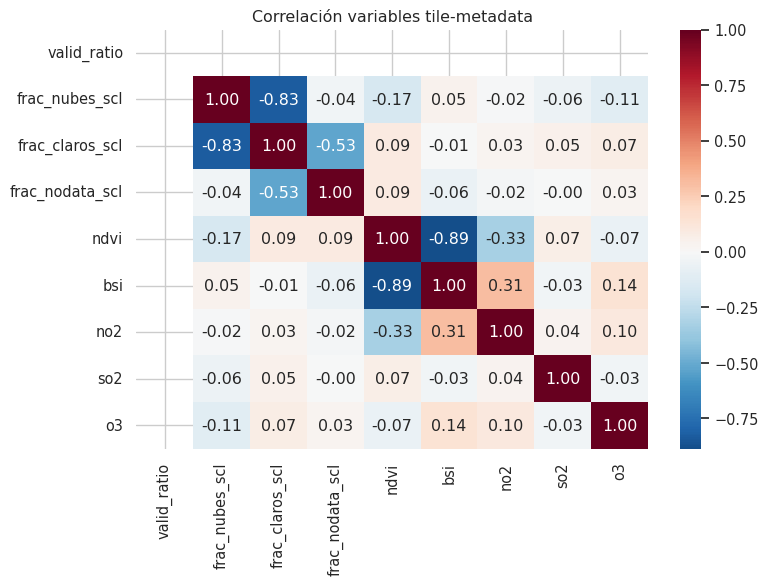

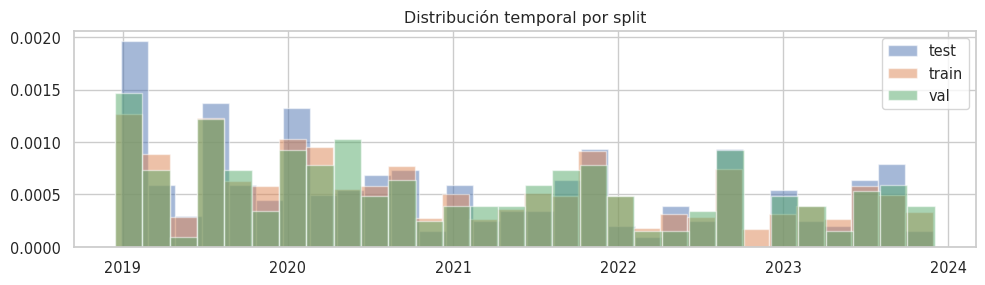

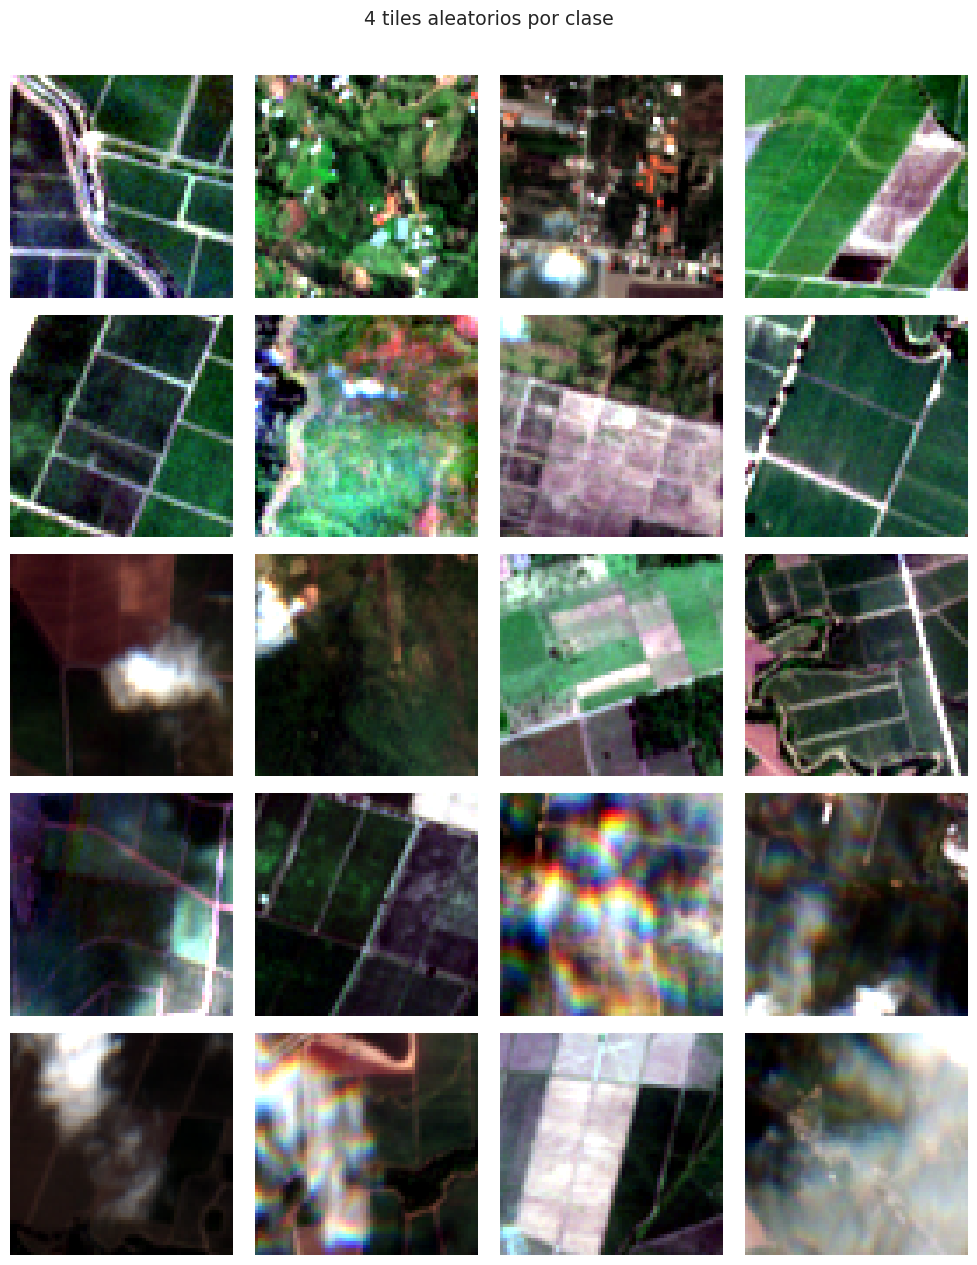


Secuencias: 30 | longitudes: [8, 8, 8, 8, 8]...
EDA guardado en: /content/eda_sit2


In [4]:
# @title EDA — tablas y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.95)
rng = np.random.default_rng(SEED)

# --- Balance global y por split ---
bal_global = df["clase"].value_counts().reindex(CLASES).rename("n")
bal_global.to_csv(EDA_DIR / "balance_global.csv")
print("=== Balance global ===\n", bal_global)

bal_split = df.groupby(["split", "clase"]).size().unstack(fill_value=0)
bal_split.to_csv(EDA_DIR / "balance_por_split.csv")
print("\n=== Balance por split ===\n", bal_split)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bal_global.plot(kind="bar", ax=axes[0], color="steelblue", rot=45)
axes[0].set_title("Muestras por clase (global)")
axes[0].set_ylabel("n")
bal_split.T.plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("Por split")
axes[1].legend(title="split", fontsize=8)
plt.tight_layout()
plt.savefig(EDA_DIR / "01_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Estadísticas numéricas por clase ---
stats = df.groupby("clase")[NUMERIC_COLS].agg(["mean", "std", "min", "max", "median"])
stats.to_csv(EDA_DIR / "estadisticas_por_clase.csv")
print("\n=== Estadísticas por clase (extracto NDVI/BSI/nubes) ===")
_cols_show = ["ndvi", "bsi", "frac_nubes_scl", "no2", "so2", "o3"]
# MultiIndex: nivel 0 = variable, nivel 1 = agregación (mean, std, ...)
print(stats.loc[:, pd.IndexSlice[_cols_show, :]].round(6))

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(data=df, x="clase", y=col, ax=axes[i], order=CLASES)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig(EDA_DIR / "02_boxplots_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Correlación (Pearson) ---
corr = df[NUMERIC_COLS].corr()
corr.to_csv(EDA_DIR / "correlacion_numericas.csv")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación variables tile-metadata")
plt.tight_layout()
plt.savefig(EDA_DIR / "03_correlacion.png", dpi=150)
plt.show()

# --- Fechas y splits ---
df["fecha_dt"] = pd.to_datetime(df["fecha"])
fig, ax = plt.subplots(figsize=(10, 3))
for sp, g in df.groupby("split"):
    ax.hist(g["fecha_dt"], bins=30, alpha=0.5, label=sp, density=True)
ax.legend()
ax.set_title("Distribución temporal por split")
plt.tight_layout()
plt.savefig(EDA_DIR / "04_fechas_por_split.png", dpi=150)
plt.show()

# --- Muestras RGB por clase ---
fig, axes = plt.subplots(len(CLASES), 4, figsize=(10, 2.5 * len(CLASES)))
for r, clase in enumerate(CLASES):
    sub = df[df["clase"] == clase]
    idxs = rng.choice(sub.index.to_numpy(), size=min(4, len(sub)), replace=False)
    for c, j in enumerate(idxs):
        tile = np.asarray(tiles_z[int(j)])
        axes[r, c].imshow(tile_to_rgb_uint8(tile))
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(clase, fontsize=8)
plt.suptitle("4 tiles aleatorios por clase", y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / "05_muestras_rgb_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Secuencias temporales (Sit. 3) ---
seq_lens = [len(s["tile_ids"]) for s in secuencias]
seq_df = pd.DataFrame({
    "n_secuencias": [len(secuencias)],
    "longitud_media": [np.mean(seq_lens)],
    "longitud_min": [min(seq_lens)],
    "longitud_max": [max(seq_lens)],
})
seq_df.to_csv(EDA_DIR / "resumen_secuencias.csv", index=False)
print(f"\nSecuencias: {len(secuencias)} | longitudes: {seq_lens[:5]}...")
print("EDA guardado en:", EDA_DIR)


## 2. EDA — calidad para entrenamiento

Informe complementario: nubes (SCL), claridad y NDVI por **split** y **clase**.
Salidas en `EDA_DIR` (`resumen_calidad_split_clase.csv`, `tiles_baja_calidad.csv`, paneles PNG).


### Paso 1 — Tabla resumen por split y clase

Mediana de `frac_nubes_scl`, `frac_claros_scl` y `ndvi` para detectar desbalance de calidad entre clases y splits.


In [5]:
# @title EDA calidad — Paso 1: mediana nubes / claros / NDVI
CALIDAD_COLS = ["frac_nubes_scl", "frac_claros_scl", "ndvi"]
rows = []
for split, gsp in df.groupby("split"):
    for clase in CLASES:
        sub = gsp[gsp["clase"] == clase]
        if sub.empty:
            continue
        row = {"split": split, "clase": clase, "n": len(sub)}
        for c in CALIDAD_COLS:
            row[f"mediana_{c}"] = float(sub[c].median())
        rows.append(row)
tab_calidad = pd.DataFrame(rows)
out_csv = EDA_DIR / "resumen_calidad_split_clase.csv"
tab_calidad.to_csv(out_csv, index=False)
print(tab_calidad.round(4).to_string(index=False))
print("\nGuardado:", out_csv)


split                  clase   n  mediana_frac_nubes_scl  mediana_frac_claros_scl  mediana_ndvi
 test contaminacion_alta_NO2  70                  0.0012                   0.9983        0.5043
 test contaminacion_alta_SO2  45                  0.0000                   1.0000        0.6717
 test          ozono_anomalo  75                  0.0029                   0.9971        0.5724
 test       vegetacion_densa  75                  0.0063                   0.9863        0.6650
 test           suelo_urbano  75                  0.0161                   0.9790        0.4719
train contaminacion_alta_NO2 324                  0.0049                   0.9946        0.4646
train contaminacion_alta_SO2 210                  0.0010                   0.9990        0.6158
train          ozono_anomalo 350                  0.0029                   0.9951        0.6138
train       vegetacion_densa 350                  0.0054                   0.9941        0.6627
train           suelo_urbano 350        

### Paso 2 — Tiles a revisar (baja calidad)

- Top **5%** con mayor `frac_nubes_scl` (peor nube).
- Outliers de NDVI por clase (|z-score| > 2.5).
Unión → `tiles_baja_calidad.csv`.


In [6]:
# @title EDA calidad — Paso 2: lista tiles_baja_calidad.csv
work = df.copy()
n_top = max(1, int(np.ceil(0.05 * len(work))))
top_nube = work.nlargest(n_top, "frac_nubes_scl").copy()
top_nube["motivo"] = "top5pct_frac_nubes"

outliers = []
for clase in CLASES:
    sub = work[work["clase"] == clase]
    if len(sub) < 8:
        continue
    mu, sig = sub["ndvi"].mean(), sub["ndvi"].std()
    if sig < 1e-9:
        continue
    z = (sub["ndvi"] - mu) / sig
    bad = sub.loc[z.abs() > 2.5].copy()
    bad["motivo"] = "outlier_ndvi_clase"
    outliers.append(bad)

lista = pd.concat([top_nube, *outliers], ignore_index=True)
lista = lista.drop_duplicates(subset=["tile_id"], keep="first")
cols_out = [
    "tile_id", "split", "clase", "motivo",
    "frac_nubes_scl", "frac_claros_scl", "ndvi", "valid_ratio", "descripcion",
]
lista = lista[[c for c in cols_out if c in lista.columns]]
out_lista = EDA_DIR / "tiles_baja_calidad.csv"
lista.to_csv(out_lista, index=False)
print(f"Tiles a revisar: {len(lista)} (top nube={len(top_nube)}, outliers NDVI={sum(len(o) for o in outliers)})")
print(lista.head(10).to_string(index=False))
print("\nGuardado:", out_lista)


Tiles a revisar: 146 (top nube=114, outliers NDVI=34)
                                             tile_id split                  clase             motivo  frac_nubes_scl  frac_claros_scl     ndvi  valid_ratio                                                                                                                                                                                                                                                                                                                                                                   descripcion
20200302T153611_20200302T153614_T18NUJ__y0576__x3392 train       vegetacion_densa top5pct_frac_nubes        0.149902         0.850098 0.555708          1.0                             Parche de Sentinel-2 con cubierta vegetal densa y saludable en la region de Cali, con bajos niveles de contaminacion atmosferica. Predominan areas verdes, cultivos o cobertura boscosa. Coordenadas (3.5954N, -76.3424O), fecha 2020-03-02. Ind

### Paso 3 — Panel visual (RGB + SCL + histograma)

Muestra hasta **N** tiles de la lista de baja calidad (3 columnas: RGB, mapa SCL, histograma de bandas).


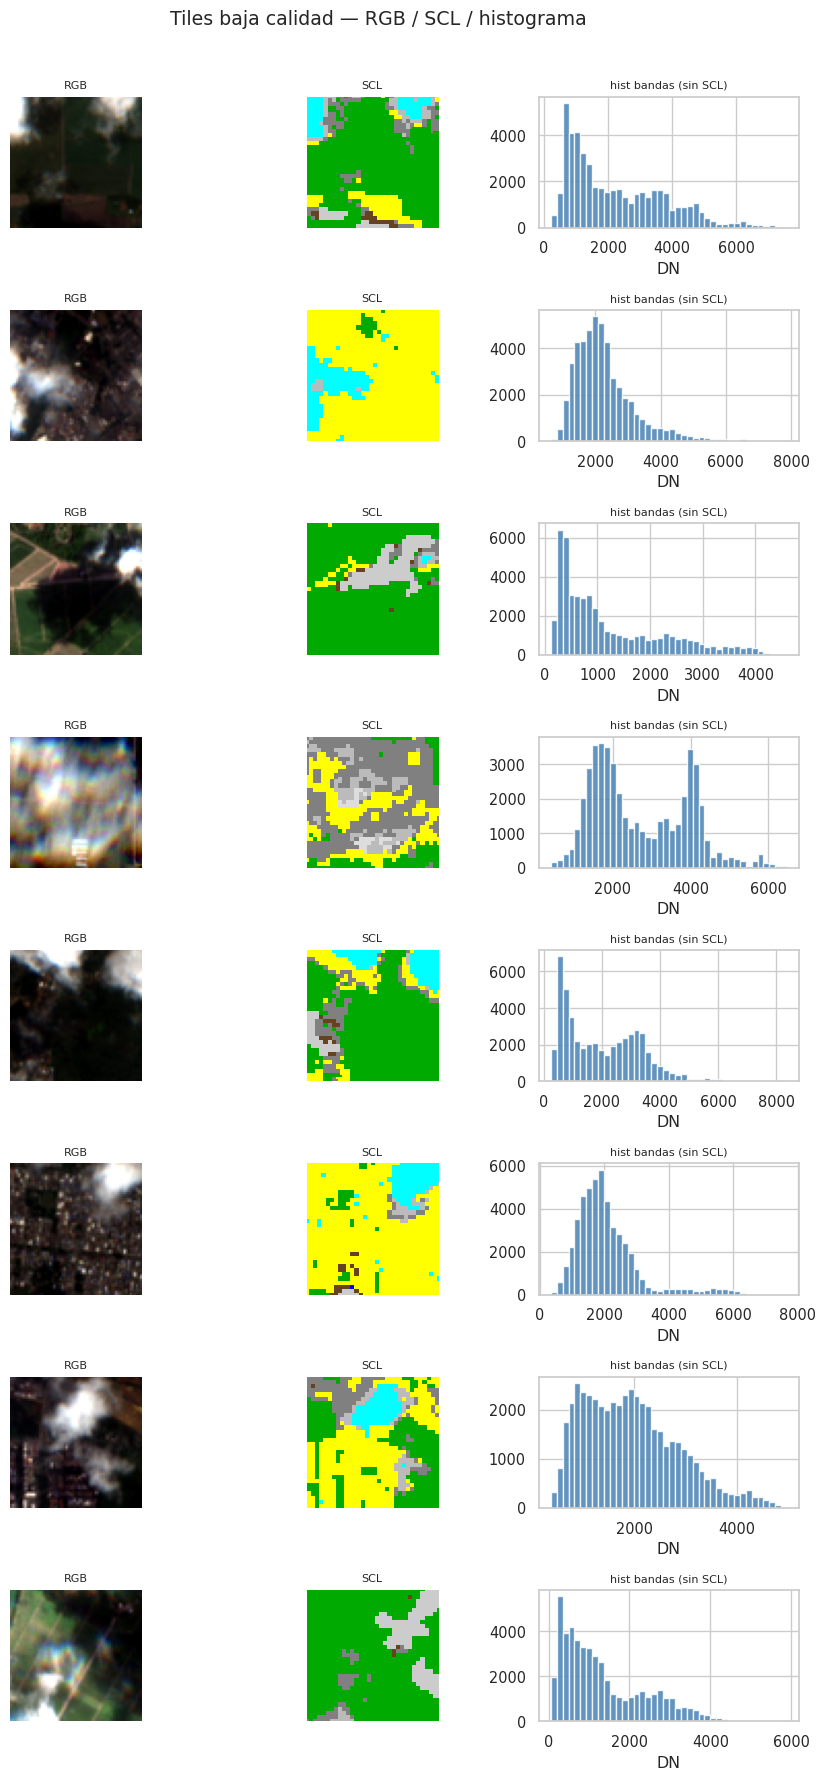

Guardado: /content/eda_sit2/06_panel_calidad_rgb_scl_hist.png


In [7]:
# @title EDA calidad — Paso 3: panel RGB + SCL + histograma
from matplotlib.colors import ListedColormap, BoundaryNorm

SCL_LABELS = {
    0: "nodata", 1: "saturado", 2: "sombra", 3: "nube", 4: "veg",
    5: "no_veg", 6: "agua", 7: "sin_clas", 8: "nube_med", 9: "cirrus",
    10: "nube_thin", 11: "nieve",
}
SCL_COLORS = [
    "#000000", "#ff0000", "#654321", "#cccccc", "#00aa00",
    "#ffff00", "#0000ff", "#808080", "#bbbbbb", "#00ffff",
    "#dddddd", "#ffffff",
]
_scl_cmap = ListedColormap(SCL_COLORS)
_scl_norm = BoundaryNorm(np.arange(-0.5, 12.5, 1), _scl_cmap.N)

def tile_scl_map(tile_13hw):
    idx_scl = _IDX_SCL if "_IDX_SCL" in dir() else BANDAS_S2.index("SCL")
    scl = np.rint(tile_13hw[idx_scl]).astype(np.int16)
    return scl

def plot_tile_panel(tile_13hw, title="", ax_rgb=None, ax_scl=None, ax_hist=None):
    if ax_rgb is not None:
        ax_rgb.imshow(tile_to_rgb_uint8(tile_13hw))
        ax_rgb.set_title("RGB", fontsize=8)
        ax_rgb.axis("off")
    if ax_scl is not None:
        scl = tile_scl_map(tile_13hw)
        im = ax_scl.imshow(scl, cmap=_scl_cmap, norm=_scl_norm, interpolation="nearest")
        ax_scl.set_title("SCL", fontsize=8)
        ax_scl.axis("off")
    if ax_hist is not None:
        vals = tile_13hw[:12].astype(np.float32).ravel()
        vals = vals[np.isfinite(vals)]
        ax_hist.hist(vals, bins=40, color="steelblue", alpha=0.85)
        ax_hist.set_title("hist bandas (sin SCL)", fontsize=8)
        ax_hist.set_xlabel("DN")
    if title and ax_rgb is not None:
        ax_rgb.set_ylabel(title, fontsize=7, rotation=0, labelpad=40, va="center")

_lista_path = EDA_DIR / "tiles_baja_calidad.csv"
if "lista" not in globals() and _lista_path.is_file():
    lista = pd.read_csv(_lista_path)
N_PANEL = min(8, len(lista)) if "lista" in globals() else 0
if N_PANEL == 0:
    print("Sin tiles en lista; ejecuta el Paso 2.")
else:
    fig, axes = plt.subplots(N_PANEL, 3, figsize=(9, 2.2 * N_PANEL))
    if N_PANEL == 1:
        axes = axes.reshape(1, -1)
    for r, (_, row) in enumerate(lista.head(N_PANEL).iterrows()):
        j = tile_zarr_index(row["tile_id"])
        tile = np.asarray(tiles_z[j])
        ttl = f"{row['tile_id'][:12]}… | {row['clase'][:12]}"
        plot_tile_panel(tile, ttl, axes[r, 0], axes[r, 1], axes[r, 2])
    plt.suptitle("Tiles baja calidad — RGB / SCL / histograma", y=1.01)
    plt.tight_layout()
    out_png = EDA_DIR / "06_panel_calidad_rgb_scl_hist.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardado:", out_png)



### Paso 4 — Reglas de calidad “estricta”

Criterio estricto (más exigente que el pipeline por defecto):
- `frac_nubes_scl` ≤ 0.15
- `frac_claros_scl` ≥ 0.90

Se reporta el % de tiles que pasan, global y por split.


In [8]:
# @title EDA calidad — Paso 4: % pasa filtro estricto
UMBRAL_NUBE_ESTRICTO = 0.15
UMBRAL_CLAROS_ESTRICTO = 0.90

df["_pasa_estricto"] = (
    (df["frac_nubes_scl"] <= UMBRAL_NUBE_ESTRICTO)
    & (df["frac_claros_scl"] >= UMBRAL_CLAROS_ESTRICTO)
)
pct_global = 100.0 * df["_pasa_estricto"].mean()
resumen_estricto = {"ambito": ["global"], "n": [len(df)], "pct_pasa_estricto": [pct_global]}
for sp, g in df.groupby("split"):
    resumen_estricto["ambito"].append(sp)
    resumen_estricto["n"].append(len(g))
    resumen_estricto["pct_pasa_estricto"].append(100.0 * g["_pasa_estricto"].mean())

tab_estricto = pd.DataFrame(resumen_estricto)
print(tab_estricto.round(2).to_string(index=False))
print(f"\nPipeline actual (ref.): nube≤0.30, claros≥0.10 → pasa {100*df['frac_nubes_scl'].le(0.30).mul(df['frac_claros_scl'].ge(0.10)).mean():.1f}%")
tab_estricto.to_csv(EDA_DIR / "pct_filtro_estricto.csv", index=False)
print("Guardado:", EDA_DIR / "pct_filtro_estricto.csv")


ambito    n  pct_pasa_estricto
global 2263              88.91
  test  340              87.94
 train 1584              89.08
   val  339              89.09

Pipeline actual (ref.): nube≤0.30, claros≥0.10 → pasa 100.0%
Guardado: /content/eda_sit2/pct_filtro_estricto.csv


## 2b. Estudio adicional del dataset (informe diagnóstico)

Complementa el EDA de calidad con los cinco analisis del informe:
data leakage temporal, auditoria texto vs visual, coherencia S5P-visual,
ozono alto vs bajo, y resumen exportable a CSV en `EDA_DIR`.


### Estudio A — Data leakage temporal (urgente)

El split es estratificado por **clase**, no por **fecha** ni **escena S2**.
Si la misma imagen satelital aporta tiles a train y val, el Recall puede estar inflado.
Salida: `leakage_temporal.csv`, `07_leakage_fechas.png`.


          par  fechas_compartidas  pct_fechas_solapadas_a  escenas_s2_compartidas  pct_escenas_solapadas_a  tiles_a  tiles_b
 train_vs_val                 163                   54.52                     180                    44.89     1584      339
train_vs_test                 155                   51.84                     185                    46.13     1584      340
  val_vs_test                 115                   64.97                     119                    57.77      339      340

Escenas S2 en train Y val: 180
Tiles afectados: 1616
img_id_s2                               split
20181215T152631_20181215T153104_T18NUJ  train    2
                                        val      1
20181218T153611_20181218T153751_T18NUJ  train    4
                                        val      1
20181223T153619_20181223T153614_T18NUJ  train    1
                                        val      3
20181228T153611_20181228T153753_T18NUJ  test     2
                                        tra

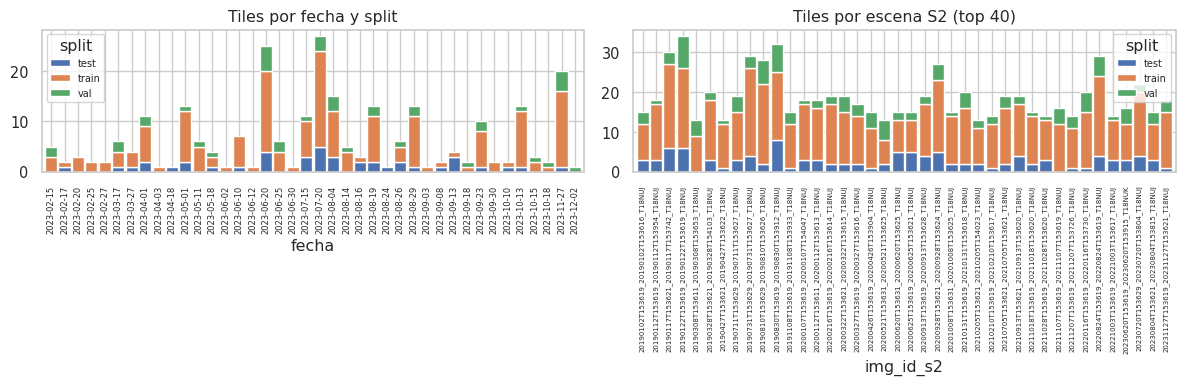

Guardado: /content/eda_sit2/leakage_temporal.csv | /content/eda_sit2/07_leakage_fechas.png


In [9]:
# @title Estudio A — leakage temporal (fechas y escenas S2)
import matplotlib.pyplot as plt

def _img_id_from_tile_id(tid: str) -> str:
    if "__y" in tid:
        return tid.split("__y")[0]
    return tid

work = df.copy()
if "img_id_s2" not in work.columns:
    work["img_id_s2"] = work["tile_id"].map(_img_id_from_tile_id)

rows_leak = []
for sp_a, sp_b in [("train", "val"), ("train", "test"), ("val", "test")]:
    fa = set(work.loc[work["split"] == sp_a, "fecha"].astype(str))
    fb = set(work.loc[work["split"] == sp_b, "fecha"].astype(str))
    fechas_sol = fa & fb
    ia = set(work.loc[work["split"] == sp_a, "img_id_s2"].astype(str))
    ib = set(work.loc[work["split"] == sp_b, "img_id_s2"].astype(str))
    escenas_sol = ia & ib
    n_a = int((work["split"] == sp_a).sum())
    n_b = int((work["split"] == sp_b).sum())
    rows_leak.append({
        "par": f"{sp_a}_vs_{sp_b}",
        "fechas_compartidas": len(fechas_sol),
        "pct_fechas_solapadas_a": 100 * len(fechas_sol) / max(1, len(fa)),
        "escenas_s2_compartidas": len(escenas_sol),
        "pct_escenas_solapadas_a": 100 * len(escenas_sol) / max(1, len(ia)),
        "tiles_a": n_a,
        "tiles_b": n_b,
    })

tab_leak = pd.DataFrame(rows_leak)
print(tab_leak.round(2).to_string(index=False))

# Tiles de la misma escena S2 en train Y val (caso mas grave)
train_esc = set(work.loc[work["split"] == "train", "img_id_s2"])
val_esc = set(work.loc[work["split"] == "val", "img_id_s2"])
esc_graves = sorted(train_esc & val_esc)
tiles_misma_escena = work[work["img_id_s2"].isin(esc_graves)].copy()
tiles_misma_escena = tiles_misma_escena.sort_values(["img_id_s2", "split"])
print(f"\nEscenas S2 en train Y val: {len(esc_graves)}")
print(f"Tiles afectados: {len(tiles_misma_escena)}")
if len(esc_graves) > 0:
    print(tiles_misma_escena.groupby(["img_id_s2", "split"]).size().head(12))

tab_leak.to_csv(EDA_DIR / "leakage_temporal.csv", index=False)
tiles_misma_escena.to_csv(EDA_DIR / "tiles_misma_escena_train_val.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], "fecha", "Tiles por fecha y split"),
    (axes[1], "img_id_s2", "Tiles por escena S2 (top 40)"),
]:
    if col == "fecha":
        ct = work.groupby(["fecha", "split"]).size().unstack(fill_value=0)
        ct.tail(40).plot(kind="bar", stacked=True, ax=ax, width=0.9)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
    else:
        top_esc = work["img_id_s2"].value_counts().head(40).index
        sub = work[work["img_id_s2"].isin(top_esc)]
        ct = sub.groupby(["img_id_s2", "split"]).size().unstack(fill_value=0)
        ct.plot(kind="bar", stacked=True, ax=ax, width=0.9)
        ax.tick_params(axis="x", rotation=90, labelsize=5)
    ax.set_title(title)
    ax.legend(title="split", fontsize=7)
plt.tight_layout()
plt.savefig(EDA_DIR / "07_leakage_fechas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", EDA_DIR / "leakage_temporal.csv", "|", EDA_DIR / "07_leakage_fechas.png")


### Estudio B — Auditoria: 10 tiles por clase (texto vs visual)

Muestra RGB + fragmento de `descripcion` para revisar si la etiqueta coincide con lo visible.
Salida: `08_auditoria_10porclase.png`, `auditoria_texto_visual.csv`.


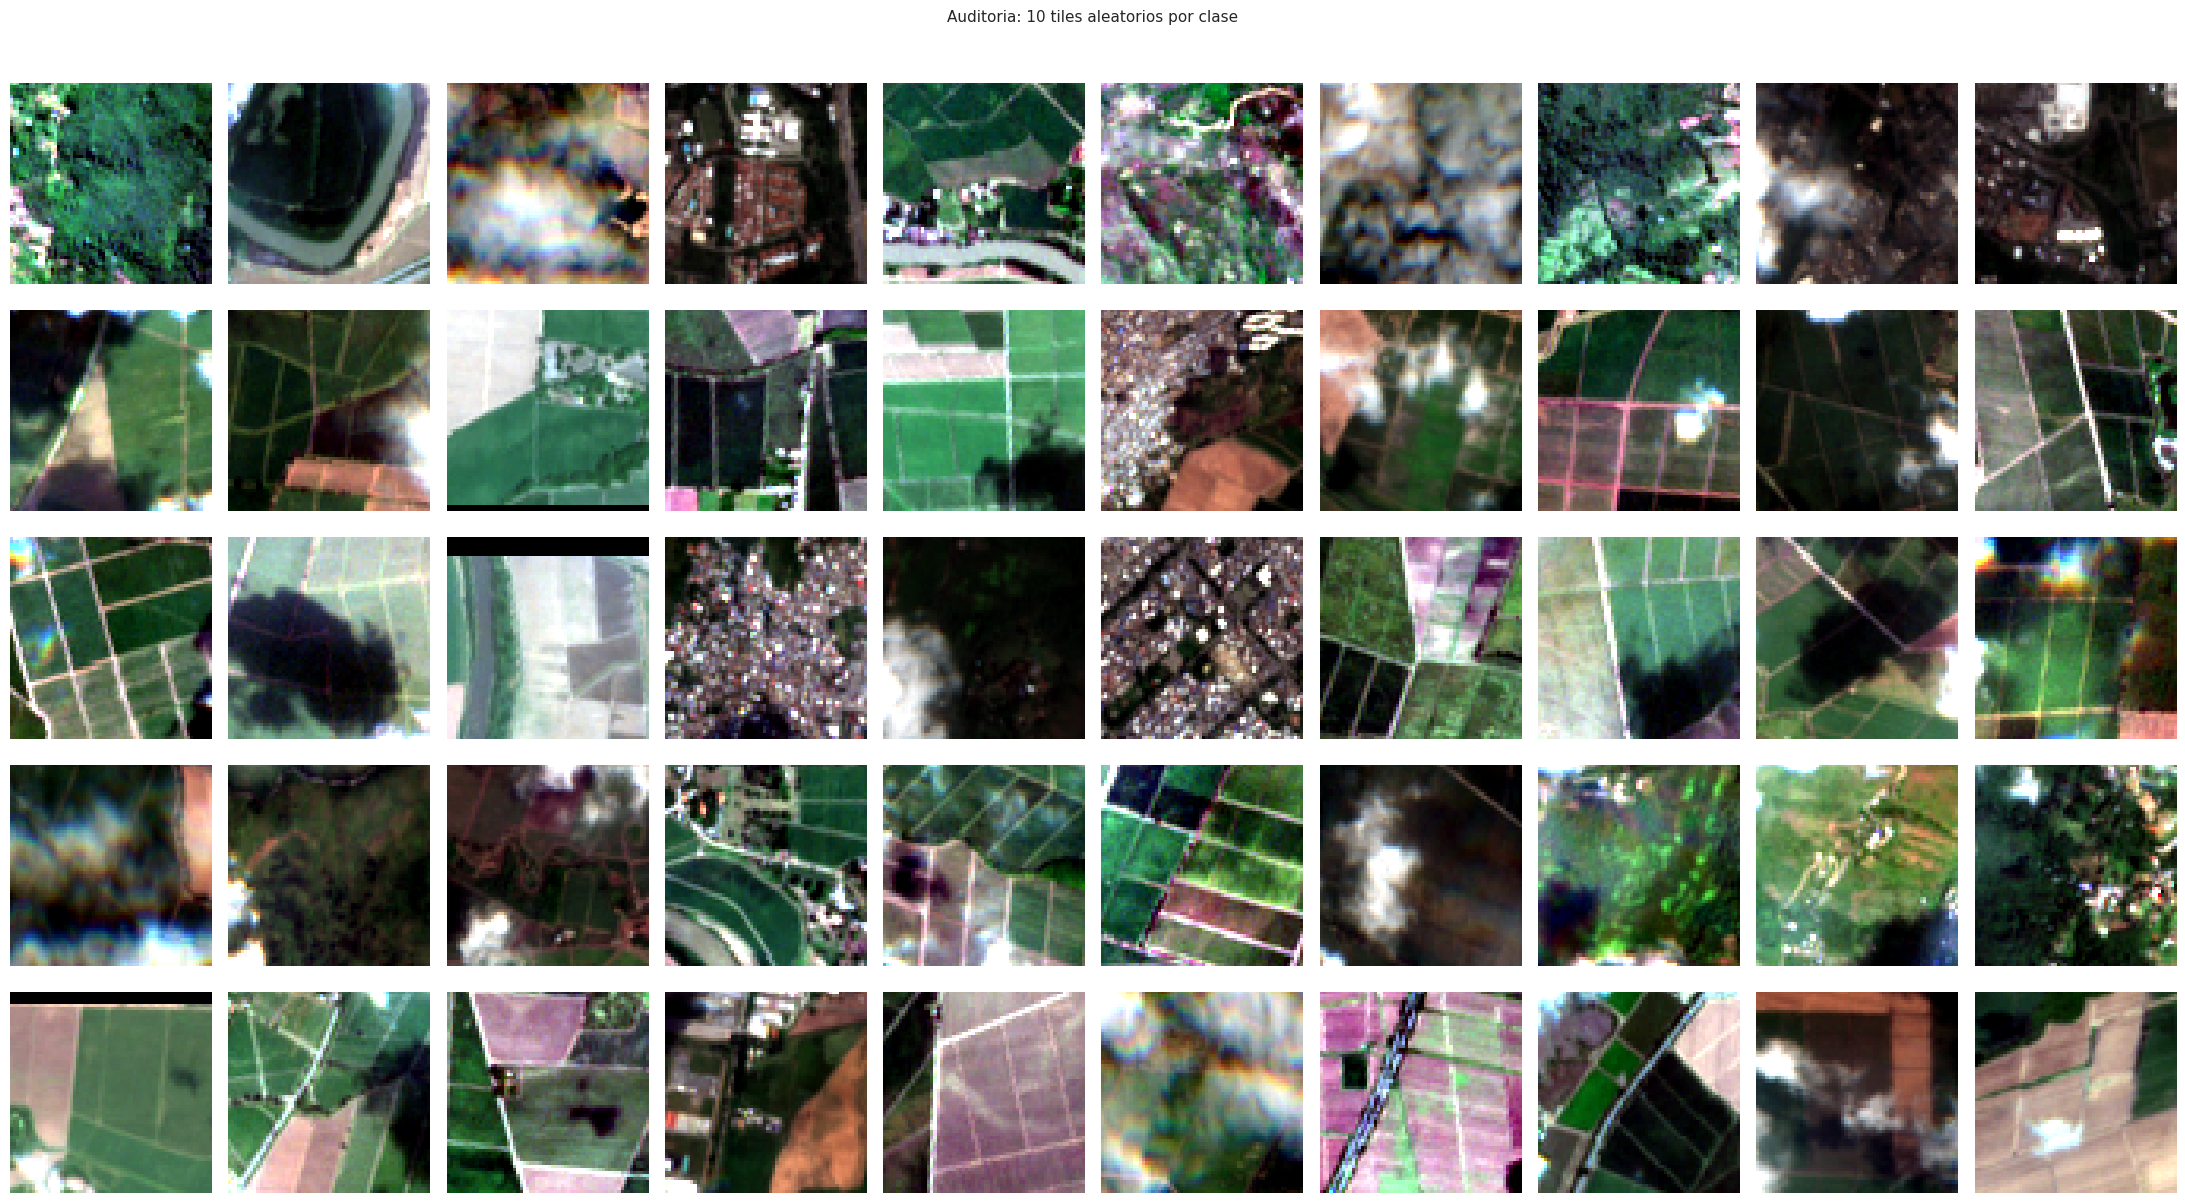

clase
contaminacion_alta_NO2    10
contaminacion_alta_SO2    10
ozono_anomalo             10
suelo_urbano              10
vegetacion_densa          10
dtype: int64

Guardado: /content/eda_sit2/auditoria_texto_visual.csv


In [10]:
# @title Estudio B — auditoria 10 tiles/clase (texto vs RGB)
rng_audit = np.random.default_rng(SEED)
N_AUDIT = 10
audit_rows = []

fig, axes = plt.subplots(len(CLASES), N_AUDIT, figsize=(2.2 * N_AUDIT, 2.4 * len(CLASES)))
if len(CLASES) == 1:
    axes = axes.reshape(1, -1)

for r, clase in enumerate(CLASES):
    sub = df[df["clase"] == clase]
    if len(sub) == 0:
        continue
    idxs = rng_audit.choice(sub.index.to_numpy(), size=min(N_AUDIT, len(sub)), replace=False)
    for c, j in enumerate(idxs):
        row = df.loc[j]
        tile = np.asarray(tiles_z[tile_zarr_index(row["tile_id"])])
        ax = axes[r, c]
        ax.imshow(tile_to_rgb_uint8(tile))
        ax.axis("off")
        if c == 0:
            ax.set_ylabel(clase.replace("contaminacion_", "").replace("_", "\n")[:18], fontsize=7)
        desc_short = str(row["descripcion"])[:55] + "..."
        audit_rows.append({
            "clase": clase,
            "tile_id": row["tile_id"],
            "split": row["split"],
            "frac_nubes": float(row["frac_nubes_scl"]),
            "ndvi": float(row["ndvi"]),
            "no2": float(row["no2"]),
            "descripcion_corta": desc_short,
        })

plt.suptitle("Auditoria: 10 tiles aleatorios por clase", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(EDA_DIR / "08_auditoria_10porclase.png", dpi=150, bbox_inches="tight")
plt.show()

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(EDA_DIR / "auditoria_texto_visual.csv", index=False)
print(audit_df.groupby("clase").size())
print("\nGuardado:", EDA_DIR / "auditoria_texto_visual.csv")


### Estudio C — Coherencia S5P vs visual

Cruza clase con valores NO2/SO2/O3 y NDVI. Detecta tiles **suelo_urbano** con NO2 alto
o **vegetacion** con contaminante extremo (posible desalineamiento grilla 3.5 km vs tile 640 m).
Salida: `coherencia_s5p_visual.csv`, scatter PNG.


Tiles sospechosos S5P-visual: 81 / 2263
motivo_sospecha
NO2_alto_pero_NDVI_alto    81
Name: count, dtype: int64


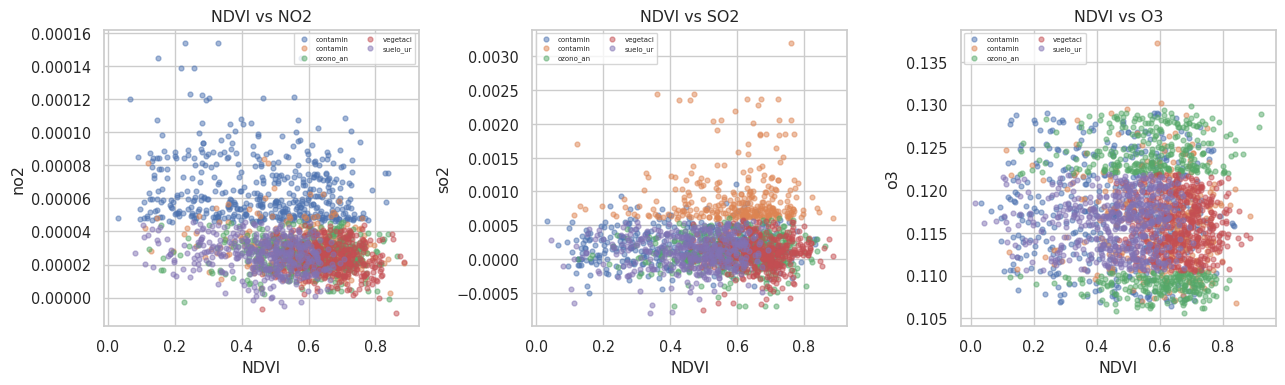

Guardado: /content/eda_sit2/coherencia_s5p_visual.csv


In [11]:
# @title Estudio C — coherencia S5P vs clase / NDVI
pct_path = DATA_DIR / "percentiles.json"
pct = json.loads(pct_path.read_text(encoding="utf-8")) if pct_path.is_file() else {}
p90_no2 = pct.get("NO2", {}).get("p90", np.nan)
p90_so2 = pct.get("SO2", {}).get("p90", np.nan)

work = df.copy()
work["no2_sobre_p90"] = work["no2"] >= p90_no2 if np.isfinite(p90_no2) else False
work["so2_sobre_p90"] = work["so2"] >= p90_so2 if np.isfinite(p90_so2) else False

# Casos sospechosos: etiqueta NO2 pero NDVI muy alto (bosque) o suelo_urbano sin NO2 alto
sospechosos = work[
    ((work["clase"] == "contaminacion_alta_NO2") & (work["ndvi"] > 0.65))
    | ((work["clase"] == "suelo_urbano") & (work["no2_sobre_p90"]))
    | ((work["clase"] == "vegetacion_densa") & (work["no2_sobre_p90"] | work["so2_sobre_p90"]))
].copy()
sospechosos["motivo_sospecha"] = np.select(
    [
        (sospechosos["clase"] == "contaminacion_alta_NO2") & (sospechosos["ndvi"] > 0.65),
        (sospechosos["clase"] == "suelo_urbano") & (sospechosos["no2_sobre_p90"]),
        (sospechosos["clase"] == "vegetacion_densa") & (sospechosos["no2_sobre_p90"]),
    ],
    ["NO2_alto_pero_NDVI_alto", "urbano_pero_NO2_p90", "veg_pero_NO2_p90"],
    default="otro",
)

print(f"Tiles sospechosos S5P-visual: {len(sospechosos)} / {len(work)}")
print(sospechosos["motivo_sospecha"].value_counts())
cols_s = ["tile_id", "split", "clase", "motivo_sospecha", "ndvi", "bsi", "no2", "so2", "o3", "frac_nubes_scl"]
sospechosos[cols_s].head(15).to_string(index=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, pol, col in zip(axes, ["NO2", "SO2", "O3"], ["no2", "so2", "o3"]):
    for clase in CLASES:
        sub = work[work["clase"] == clase]
        ax.scatter(sub["ndvi"], sub[col], s=12, alpha=0.5, label=clase[:8])
    ax.set_xlabel("NDVI")
    ax.set_ylabel(col)
    ax.set_title(f"NDVI vs {pol}")
    ax.legend(fontsize=5, ncol=2)
plt.tight_layout()
plt.savefig(EDA_DIR / "09_scatter_ndvi_contaminantes.png", dpi=150)
plt.show()

sospechosos.to_csv(EDA_DIR / "coherencia_s5p_visual.csv", index=False)
print("Guardado:", EDA_DIR / "coherencia_s5p_visual.csv")


### Estudio D — Ozono anomalo: alto (>=p90) vs bajo (<=p25)

El pipeline agrupa ambos en `ozono_anomalo` con el **mismo texto base**.
Aquí se separan usando `percentiles.json` y se comparan NDVI y fraccion de nubes.
Salida: `ozono_alto_vs_bajo.csv`, barras comparativas.


subtipo_ozono
ozono_ALTO_p90    283
ozono_BAJO_p25    217
Name: count, dtype: int64

Mediana NDVI / nubes por subtipo:
                  ndvi  frac_nubes_scl  frac_claros_scl
subtipo_ozono                                          
ozono_ALTO_p90  0.5842          0.0000           1.0000
ozono_BAJO_p25  0.6245          0.0068           0.9932

Ejemplo texto ALTO:
  Tile de Sentinel-2 sobre Cali donde la columna de ozono troposferico presenta un valor atipico, ya sea por formacion fotoquimica en epocas de alta radiacion solar o por condiciones meteorologicas part

Ejemplo texto BAJO:
  Tile de Sentinel-2 sobre Cali donde la columna de ozono troposferico presenta un valor atipico, ya sea por formacion fotoquimica en epocas de alta radiacion solar o por condiciones meteorologicas part

>> Misma plantilla base; solo cambian numeros O3/NDVI.


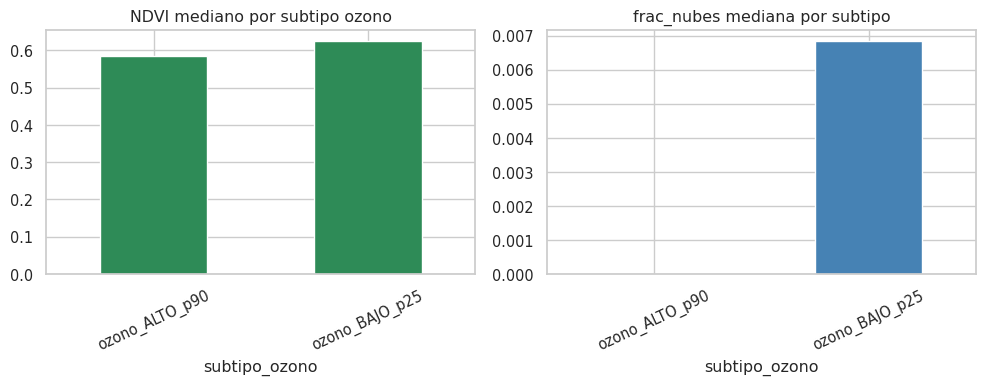

Guardado: /content/eda_sit2/ozono_alto_vs_bajo.csv


In [12]:
# @title Estudio D — ozono alto vs bajo (misma clase, textos identicos)
pct = json.loads((DATA_DIR / "percentiles.json").read_text(encoding="utf-8"))
p25_o3 = pct["O3"]["p25"]
p90_o3 = pct["O3"]["p90"]

oz = df[df["clase"] == "ozono_anomalo"].copy()
oz["subtipo_ozono"] = np.select(
    [oz["o3"] >= p90_o3, oz["o3"] <= p25_o3],
    ["ozono_ALTO_p90", "ozono_BAJO_p25"],
    default="ozono_intermedio",
)
print(oz["subtipo_ozono"].value_counts())
print("\nMediana NDVI / nubes por subtipo:")
print(oz.groupby("subtipo_ozono")[["ndvi", "frac_nubes_scl", "frac_claros_scl"]].median().round(4))

# Muestra que el texto es identico en estructura
ej_alto = oz[oz["subtipo_ozono"] == "ozono_ALTO_p90"].iloc[0]["descripcion"] if (oz["subtipo_ozono"] == "ozono_ALTO_p90").any() else ""
ej_bajo = oz[oz["subtipo_ozono"] == "ozono_BAJO_p25"].iloc[0]["descripcion"] if (oz["subtipo_ozono"] == "ozono_BAJO_p25").any() else ""
print("\nEjemplo texto ALTO:\n ", ej_alto[:200])
print("\nEjemplo texto BAJO:\n ", ej_bajo[:200])
print("\n>> Misma plantilla base; solo cambian numeros O3/NDVI.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
oz.groupby("subtipo_ozono")["ndvi"].median().plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("NDVI mediano por subtipo ozono")
axes[0].tick_params(axis="x", rotation=25)
oz.groupby("subtipo_ozono")["frac_nubes_scl"].median().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("frac_nubes mediana por subtipo")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(EDA_DIR / "10_ozono_alto_vs_bajo.png", dpi=150)
plt.show()

oz_out = oz[["tile_id", "split", "o3", "subtipo_ozono", "ndvi", "descripcion"]]
oz_out.to_csv(EDA_DIR / "ozono_alto_vs_bajo.csv", index=False)
print("Guardado:", EDA_DIR / "ozono_alto_vs_bajo.csv")


## 3. Analisis de Completitud Temporal para ConvLSTM (Sit. 3)

**Objetivo:** Determinar cuantas secuencias temporales de 8 tiles consecutivos podemos formar
con los datos disponibles para entrenar el ConvLSTM de la Situacion 3.

Esto es **critico** porque el ConvLSTM necesita secuencias de la misma ubicacion a lo largo del tiempo.
El dataset actual tiene **30 secuencias pre-armadas** (de 8 fechas c/u), pero para un entrenamiento
robusto necesitamos muchas mas. Aqui exploramos la completitud temporal variando la resolucion
de la grilla espacial.

Resultado clave: a resolucion 0.05° (~5.5 km, que coincide con la grilla de Sentinel-5P),
podemos extraer **~860 secuencias** con sliding window usando solo datos 2020-2023.

In [13]:
# @title Analisis Temporal - Paso 1: Cobertura por ubicacion (distintas grillas)
from collections import Counter

print("=== COBERTURA TEMPORAL A DISTINTAS RESOLUCIONES DE GRILLA (2020-2023) ===")

# Determinar celdas a distintas resoluciones
resoluciones = {
    "0.01° (~1.1 km)": 0.01,
    "0.025° (~2.8 km)": 0.025,
    "0.05° (~5.5 km)": 0.05,
    "0.1° (~11 km)": 0.1,
}

for label, res in resoluciones.items():
    df[f"celda_{res}"] = (df["centroide_lat"] / res).round() * res
    df[f"celda_{res}_lon"] = (df["centroide_lon"] / res).round() * res
    mask_yr = (df["fecha_dt"] >= "2020-01-01") & (df["fecha_dt"] <= "2023-12-31")
    df_periodo = df[mask_yr].copy()

    # Agrupar por celda
    celda_grp = df_periodo.groupby([f"celda_{res}", f"celda_{res}_lon"]).agg(
        n_fechas=("fecha", "nunique"),
        n_tiles=("tile_id", "count"),
        fecha_min=("fecha_dt", "min"),
        fecha_max=("fecha_dt", "max")
    ).reset_index()

    n_celdas = len(celda_grp)
    n_celdas_suf = (celda_grp["n_fechas"] >= 8).sum()

    # Calcular secuencias sliding window
    total_seq = 0
    for _, row in celda_grp.iterrows():
        lat, lon = row[f"celda_{res}"], row[f"celda_{res}_lon"]
        fechas = sorted(df_periodo[
            (df_periodo[f"celda_{res}"] == lat) &
            (df_periodo[f"celda_{res}_lon"] == lon)
        ]["fecha"].unique())
        if len(fechas) >= 8:
            total_seq += len(fechas) - 7

    # Gaps promedio
    gaps = []
    for _, row in celda_grp.iterrows():
        lat, lon = row[f"celda_{res}"], row[f"celda_{res}_lon"]
        fechas = sorted(pd.to_datetime(df_periodo[
            (df_periodo[f"celda_{res}"] == lat) &
            (df_periodo[f"celda_{res}_lon"] == lon)
        ]["fecha"].unique()))
        if len(fechas) >= 2:
            diffs = (pd.Series(fechas).diff().dt.days.dropna())
            gaps.extend(diffs.tolist())

    gap_medio = pd.Series(gaps).mean() if gaps else 0

    print(f"\n{label}:")
    print(f"  Celdas con datos: {n_celdas}")
    print(f"  Celdas con >=8 fechas: {n_celdas_suf}")
    print(f"  Secuencias sliding window (seq_len=8): {total_seq}")
    print(f"  Gap medio entre fechas: {gap_medio:.0f} dias")

# Analisis de las 30 secuencias pre-armadas
print("\n=== ANALISIS DE LAS 30 SECUENCIAS PRE-ARMADAS ===")
print(f"Total: {len(secuencias)}")
celdas_seq = [(s["celda_lat"], s["celda_lon"]) for s in secuencias]
print(f"Celdas unicas (res 0.1°): {len(set(celdas_seq))}: {Counter(celdas_seq)}")

gaps_seq = []
for s in secuencias:
    fechas = sorted(pd.to_datetime(s["fechas"]))
    for i in range(len(fechas)-1):
        gaps_seq.append((fechas[i+1] - fechas[i]).days)
gaps_s = pd.Series(gaps_seq)
print(f"Gap promedio entre tiles: {gaps_s.mean():.0f} dias")
print(f"Gap mediano: {gaps_s.median():.0f} dias")
print(f"Gaps <= 5 dias: {((gaps_s <= 5).mean()*100):.0f}%")
print(f"Gaps <= 15 dias: {((gaps_s <= 15).mean()*100):.0f}%")
print(f"Gaps <= 30 dias: {((gaps_s <= 30).mean()*100):.0f}%")

=== COBERTURA TEMPORAL A DISTINTAS RESOLUCIONES DE GRILLA (2020-2023) ===

0.01° (~1.1 km):
  Celdas con datos: 751
  Celdas con >=8 fechas: 2
  Secuencias sliding window (seq_len=8): 3
  Gap medio entre fechas: 363 dias

0.025° (~2.8 km):
  Celdas con datos: 207
  Celdas con >=8 fechas: 82
  Secuencias sliding window (seq_len=8): 421
  Gap medio entre fechas: 153 dias

0.05° (~5.5 km):
  Celdas con datos: 63
  Celdas con >=8 fechas: 50
  Secuencias sliding window (seq_len=8): 863
  Gap medio entre fechas: 62 dias

0.1° (~11 km):
  Celdas con datos: 16
  Celdas con >=8 fechas: 16
  Secuencias sliding window (seq_len=8): 815
  Gap medio entre fechas: 25 dias

=== ANALISIS DE LAS 30 SECUENCIAS PRE-ARMADAS ===
Total: 30
Celdas unicas (res 0.1°): 3: Counter({(3.5, -76.5): 15, (3.4000000000000004, -76.3): 8, (3.4000000000000004, -76.5): 7})
Gap promedio entre tiles: 16 dias
Gap mediano: 10 dias
Gaps <= 5 dias: 38%
Gaps <= 15 dias: 70%
Gaps <= 30 dias: 90%


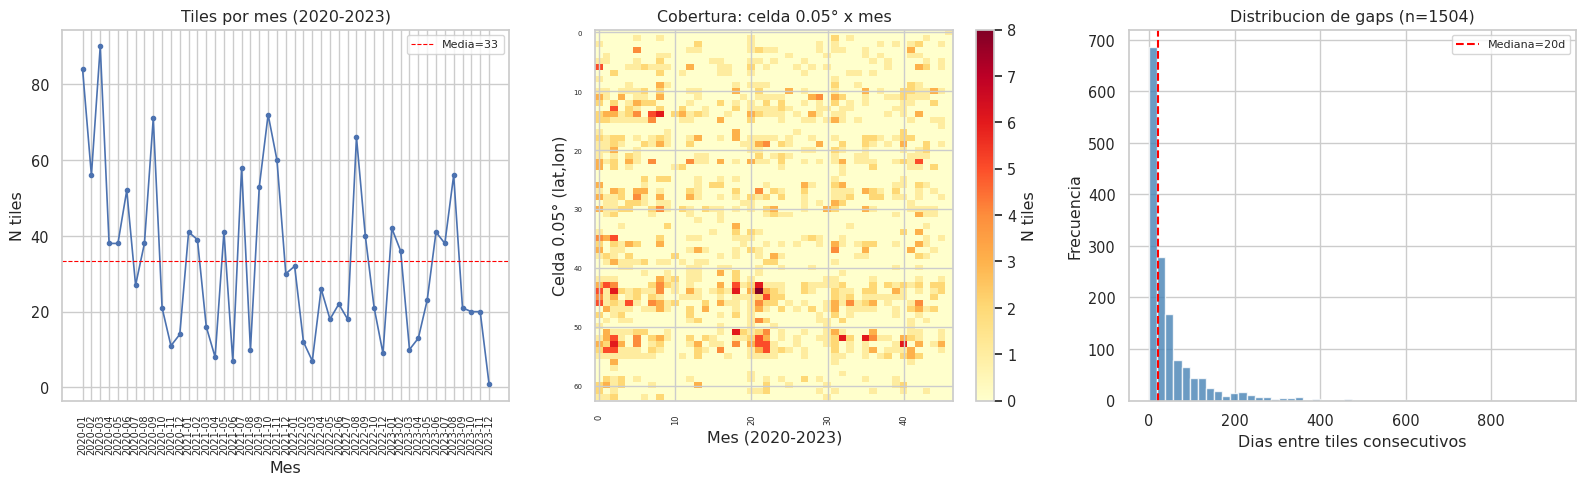

Guardado: /content/eda_sit2/11_completitud_temporal.png


In [15]:
# @title Analisis Temporal - Paso 2: Visualizacion de cobertura
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd  # Aseguramos la importación de pandas

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Grafico 1: Tiles por mes (serie temporal) ---
df["anio_mes"] = df["fecha_dt"].dt.to_period("M")
mask_yr = (df["fecha_dt"] >= "2020-01-01") & (df["fecha_dt"] <= "2023-12-31")
tiles_por_mes = df[mask_yr].groupby("anio_mes").size()

axes[0].plot(tiles_por_mes.index.astype(str), tiles_por_mes.values, marker="o", linewidth=1.2, markersize=3)
axes[0].set_title("Tiles por mes (2020-2023)")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("N tiles")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].axhline(y=tiles_por_mes.mean(), color="red", linestyle="--", linewidth=0.8, label=f"Media={tiles_por_mes.mean():.0f}")
axes[0].legend(fontsize=8)

# --- Grafico 2: Heatmap de cobertura (celda 0.05° x mes) ---
df["celda_0.05"] = (df["centroide_lat"] / 0.05).round() * 0.05
df["celda_0.05_lon"] = (df["centroide_lon"] / 0.05).round() * 0.05
df20 = df[mask_yr].copy()
df20["mes_anio"] = df20["fecha_dt"].dt.to_period("M").astype(str)

# Crear matriz de presencia: celda x mes
heat = df20.groupby(["celda_0.05", "celda_0.05_lon", "mes_anio"]).size().reset_index(name="n")
heat_pivot = heat.pivot_table(index=["celda_0.05", "celda_0.05_lon"], columns="mes_anio", values="n", fill_value=0)

im = axes[1].imshow(heat_pivot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
axes[1].set_title("Cobertura: celda 0.05° x mes")
axes[1].set_xlabel("Mes (2020-2023)")
axes[1].set_ylabel("Celda 0.05° (lat,lon)")
axes[1].tick_params(axis="x", labelsize=6, rotation=90)
axes[1].tick_params(axis="y", labelsize=5)
plt.colorbar(im, ax=axes[1], label="N tiles")

# --- Grafico 3: Distribucion de gaps entre fechas consecutivas ---
# Optimización: Usamos diff() por grupo, eliminando los bucles manuales lentos
df20 = df20.sort_values("fecha_dt")
gaps_series = df20.groupby(["celda_0.05", "celda_0.05_lon"])["fecha_dt"].diff().dt.days.dropna()

if not gaps_series.empty:
    axes[2].hist(gaps_series, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[2].axvline(x=gaps_series.median(), color="red", linestyle="--", label=f"Mediana={gaps_series.median():.0f}d")
    axes[2].set_title(f"Distribucion de gaps (n={len(gaps_series)})")
    axes[2].set_xlabel("Dias entre tiles consecutivos")
    axes[2].set_ylabel("Frecuencia")
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(EDA_DIR / "11_completitud_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", EDA_DIR / "11_completitud_temporal.png")

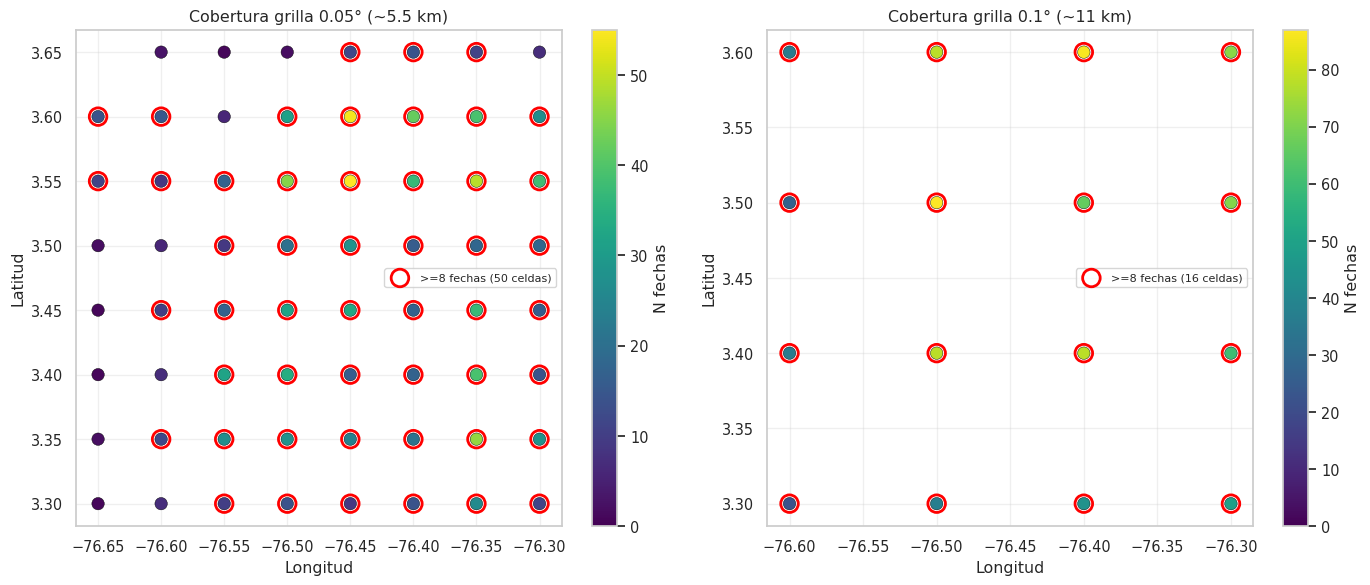

Guardado: /content/eda_sit2/12_mapa_cobertura_temporal.png


In [16]:
# @title Analisis Temporal - Paso 3: Mapa de celdas con suficientes fechas

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (res, label) in enumerate([(0.05, "0.05° (~5.5 km)"), (0.1, "0.1° (~11 km)")]):
    celda_lat = (df20["centroide_lat"] / res).round() * res
    celda_lon = (df20["centroide_lon"] / res).round() * res

    # Contar fechas por celda
    celda_counts = df20.groupby([celda_lat, celda_lon]).agg(
        n_fechas=("fecha", "nunique")
    ).reset_index()
    celda_counts.columns = ["lat", "lon", "n_fechas"]

    sc = axes[idx].scatter(
        celda_counts["lon"], celda_counts["lat"],
        c=celda_counts["n_fechas"], cmap="viridis", s=80,
        edgecolor="black", linewidth=0.3,
        norm=mcolors.Normalize(vmin=0, vmax=celda_counts["n_fechas"].max())
    )
    axes[idx].set_title(f"Cobertura grilla {label}")
    axes[idx].set_xlabel("Longitud")
    axes[idx].set_ylabel("Latitud")
    plt.colorbar(sc, ax=axes[idx], label="N fechas")
    axes[idx].grid(True, alpha=0.3)

    # Marcar celdas con >=8 fechas
    suficientes = celda_counts[celda_counts["n_fechas"] >= 8]
    axes[idx].scatter(
        suficientes["lon"], suficientes["lat"],
        facecolors="none", edgecolors="red", s=160, linewidths=2,
        label=f">=8 fechas ({len(suficientes)} celdas)"
    )
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig(EDA_DIR / "12_mapa_cobertura_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", EDA_DIR / "12_mapa_cobertura_temporal.png")

In [17]:
# @title Analisis Temporal - Paso 4: Conclusion y resumen para ConvLSTM
print("========================================")
print("  RESUMEN: COMPLETITUD TEMPORAL 2020-2023")
print("========================================")

# Cifras clave
n_total_2020_2023 = mask_yr.sum()
pct_cobertura = n_total_2020_2023 / len(df) * 100

# Secuencias a 0.05° (recomendada)
celda_lat_005 = (df20["centroide_lat"] / 0.05).round() * 0.05
celda_lon_005 = (df20["centroide_lon"] / 0.05).round() * 0.05
celda_005_grp = df20.groupby([celda_lat_005, celda_lon_005]).agg(
    n_fechas=("fecha", "nunique")
)

n_celdas_005 = len(celda_005_grp)
n_celdas_005_suf = (celda_005_grp["n_fechas"] >= 8).sum()

total_seq = 0
for (lat, lon), row in celda_005_grp.iterrows():
    fechas = sorted(df20[
        (celda_lat_005 == lat) & (celda_lon_005 == lon)
    ]["fecha"].unique())
    if len(fechas) >= 8:
        total_seq += len(fechas) - 7

print(f"\nDataset total: {len(df)} tiles")
print(f"Tiles en 2020-2023: {n_total_2020_2023} ({pct_cobertura:.0f}% del total)")
print(f"\nA resolucion 0.05° (~5.5 km):")
print(f"  Celdas totales: {n_celdas_005}")
print(f"  Celdas con >=8 fechas: {n_celdas_005_suf}")
print(f"  Secuencias sliding window (8 pasos): ~{total_seq}")

print(f"\nEstrategia recomendada para ConvLSTM (Sit. 3):")
print(f"  1. Usar grilla 0.05° que coincide con resolucion S5P")
print(f"  2. Para cada celda con >=8 fechas, crear secuencias sliding window")
print(f"  3. Cada secuencia usa tiles S2 -> embeddings CLIP 256-d")
print(f"  4. Target = valor S5P de la fecha siguiente (convertido a ug/m3)")
print(f"  5. Total estimado: ~{total_seq} muestras de entrenamiento")
print(f"\nIMPORTANTE: Esto supone ~10-20x mas datos que las 30 secuencias originales.")
print(f"   Para alcanzar los KPIs de la Sit. 3, este escalado es necesario.")

# Guardar resumen
resumen_temporal = {
    "periodo": "2020-01-01 a 2023-12-31",
    "tiles_en_periodo": int(n_total_2020_2023),
    "celdas_005_total": int(n_celdas_005),
    "celdas_005_con_8_fechas": int(n_celdas_005_suf),
    "secuencias_sliding_window_estimadas": int(total_seq),
    "secuencias_originales": len(secuencias),
    "recomendacion": "Usar grilla 0.05° con sliding window para generar dataset de entrenamiento ConvLSTM",
}

import json
with open(EDA_DIR / "resumen_completitud_temporal.json", "w") as f:
    json.dump(resumen_temporal, f, indent=2)
print(f"\nResumen guardado en: {EDA_DIR / 'resumen_completitud_temporal.json'}")

  RESUMEN: COMPLETITUD TEMPORAL 2020-2023

Dataset total: 2263 tiles
Tiles en 2020-2023: 1567 (69% del total)

A resolucion 0.05° (~5.5 km):
  Celdas totales: 63
  Celdas con >=8 fechas: 50
  Secuencias sliding window (8 pasos): ~863

Estrategia recomendada para ConvLSTM (Sit. 3):
  1. Usar grilla 0.05° que coincide con resolucion S5P
  2. Para cada celda con >=8 fechas, crear secuencias sliding window
  3. Cada secuencia usa tiles S2 -> embeddings CLIP 256-d
  4. Target = valor S5P de la fecha siguiente (convertido a ug/m3)
  5. Total estimado: ~863 muestras de entrenamiento

IMPORTANTE: Esto supone ~10-20x mas datos que las 30 secuencias originales.
   Para alcanzar los KPIs de la Sit. 3, este escalado es necesario.

Resumen guardado en: /content/eda_sit2/resumen_completitud_temporal.json


### Conclusiones del analisis de completitud temporal

1. **Las 30 secuencias pre-armadas son insuficientes** para entrenar un ConvLSTM que alcance los KPIs de la Sit. 3.
2. **A resolucion 0.05° (~5.5 km)** tenemos cobertura suficiente para generar **~860 secuencias** sliding window en 2020-2023.
3. **Los gaps temporales son grandes** (mediana ~15 dias en las secuencias originales). El ConvLSTM debe manejar secuencias irregulares.
4. **Estrategia:** agrupar tiles por celda de 0.05°, ordenar por fecha, y usar ventanas deslizantes de 8 pasos.
5. Para la inferencia en produccion, se usara el enfoque de **vecinos espaciales** (KDTree) con radio configurable.

**Proximo paso:** usar este analisis para generar el dataset de entrenamiento del ConvLSTM en un script separado.